In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
data = pd.read_csv('Bitcoin Historical Data.csv')
df = pd.read_csv('Bitcoin Historical Data.csv')
data.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,"Aug 02, 2020","11,105.8","11,802.6","12,061.1","10,730.7",698.62K,-5.91%
1,"Aug 01, 2020","11,803.1","11,333.2","11,847.7","11,226.1",611.47K,4.14%
2,"Jul 31, 2020","11,333.4","11,096.5","11,434.8","10,964.6",530.95K,2.14%
3,"Jul 30, 2020","11,096.2","11,105.8","11,164.4","10,861.6",501.14K,-0.09%
4,"Jul 29, 2020","11,105.9","10,908.4","11,336.5","10,771.8",576.83K,1.81%


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3669 entries, 0 to 3668
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Date      3669 non-null   str  
 1   Price     3669 non-null   str  
 2   Open      3669 non-null   str  
 3   High      3669 non-null   str  
 4   Low       3669 non-null   str  
 5   Vol.      3669 non-null   str  
 6   Change %  3669 non-null   str  
dtypes: str(7)
memory usage: 200.8 KB


In [4]:
data.describe()

,Date,Price,Open,High,Low,Vol.,Change %
count,3669,3669,3669,3669,3669,3669,3669
unique,3669,2718,2712,2708,2712,3275,1391
top,"Aug 02, 2020",0.1,0.1,0.1,0.1,1.05M,0.00%
freq,1,100,100,97,101,6,425


In [5]:
data["Date"] = pd.to_datetime(data["Date"])

In [6]:
data["Date"].dt.day
data["Date"].dt.month
data["Date"].dt.day
data["Date"].dt.weekday

0       6
1       5
2       4
3       3
4       2
       ..
3664    3
3665    2
3666    1
3667    0
3668    6
Name: Date, Length: 3669, dtype: int32

In [ ]:
# df['duration'] = pd.to_timedelta(df["Date"]).df.total_seconds()
# resampling 
data  = data.set_index("Date")

In [8]:
data.head()

,Price,Open,High,Low,Vol.,Change %
Date,,,,,,
2020-08-02,"11,105.8","11,802.6","12,061.1","10,730.7",698.62K,-5.91%
2020-08-01,"11,803.1","11,333.2","11,847.7","11,226.1",611.47K,4.14%
2020-07-31,"11,333.4","11,096.5","11,434.8","10,964.6",530.95K,2.14%
2020-07-30,"11,096.2","11,105.8","11,164.4","10,861.6",501.14K,-0.09%
2020-07-29,"11,105.9","10,908.4","11,336.5","10,771.8",576.83K,1.81%


In [9]:
# data["Price"].apply(lambda x: x.replace(",", ""))
# to apply cahgne to all the columns which in this case we are converting from str to int


data[["Price", "Open", "High", "Low"]] = data[["Price", "Open", "High", "Low"]].apply(lambda s: [float(x.replace(",", "")) for x in s])

## The use of Resample in pandas:
The df.resample() method in pandas is primarily used for frequency conversion and resampling of time series data. It is a powerful tool for grouping time-indexed data into different time bins (e.g., from daily to monthly) and then applying an aggregation function (like mean(), sum(), etc.) to those bins. 

This method is particularly useful when you have time series data and want to analyze it at different time intervals. For example, you can resample daily data into monthly data by taking the mean of each month's values.

basic example: 
```python 
import pandas as pd
import numpy as np
# Create a time series data
date_range = pd.date_range(start='2020-01-01', end='2020-12-31', freq='D')
data = np.random.rand(len(date_range))
df = pd.DataFrame(data, index=date_range, columns=['Value'])
# Resample the data to monthly frequency and calculate the mean
monthly_mean = df.resample('M').mean()
print(monthly_mean)
```In this example, we create a daily time series data for the year 2020 and then resample it to monthly frequency by calculating the mean of the values for each month. The resulting DataFrame will contain the average value for each month in the year 2020.

<Axes: xlabel='Date'>

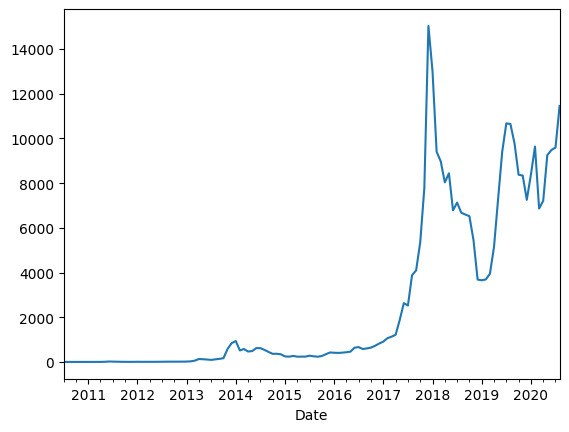

In [10]:
data.resample("MS")["Price"].mean().plot()

<Axes: xlabel='Date'>

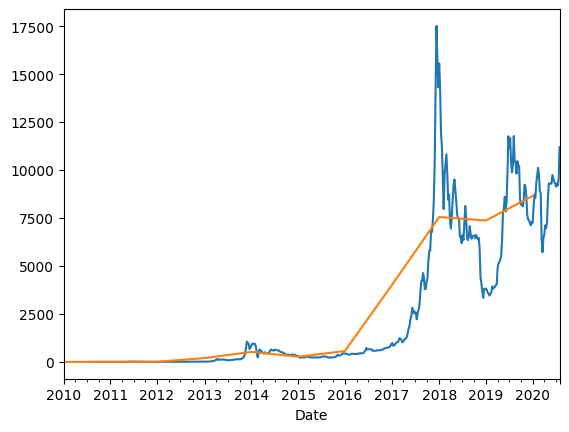

In [11]:
data.resample("W")["Price"].mean().plot() #year
data.resample("YS")["Price"].mean().plot() #year


In [13]:
?df.resample

Signature:
df.resample(
    rule,
    closed: "Literal['right', 'left'] | None" = None,
    label: "Literal['right', 'left'] | None" = None,
    convention: "Literal['start', 'end', 's', 'e']" = 'start',
    on: 'Level | None' = None,
    level: 'Level | None' = None,
    origin: 'str | TimestampConvertibleTypes' = 'start_day',
    offset: 'TimedeltaConvertibleTypes | None' = None,
    group_keys: 'bool' = False,
) -> 'Resampler'
Docstring:
Resample time-series data.

Convenience method for frequency conversion and resampling of time series.
The object must have a datetime-like index (`DatetimeIndex`, `PeriodIndex`,
or `TimedeltaIndex`), or the caller must pass the label of a datetime-like
series/index to the ``on``/``level`` keyword parameter.

Parameters
----------
rule : DateOffset, Timedelta or str
    The offset string or object representing target conversion.
closed : {{'right', 'left'}}, default None
    Which side of bin interval is closed. The default is 'left'
    for all fre